# Практика по обучению моделей

В этом практическом задании мы закрепим на практике как обучать модели в tensorflow на синтетических данных. В задачах ниже необходимо получить точность выше 90%. Советуем не сдаваться на этом -- везде реально получить 100%. А в последнем задании можно получить бонусные баллы за модель с минимальным количеством параметров.

In [2]:
! pip install tensorflow
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
import numpy as np
#tf.enable_eager_execution()
print(tf.__version__)

2.19.0


In [10]:
#@title
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, Normalize
from sklearn.metrics import accuracy_score


%matplotlib inline
np.random.seed(10)

colors = ['red', "blue"]
labels_cmap = ListedColormap(colors, 2)
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # R -> W -> B
main_cmap = LinearSegmentedColormap.from_list("main_scheme", colors, N=300)

def show_data(X, y):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], s=120, color=labels_cmap(y))


def show_descision_boundary(clf, limits, binary=False, X=None, y=None, n_lines=10, show_lines=False,
                           figsize=(5, 5), ax=None):
    if limits is None:
        if X is not None:
            xs = [X[:, 0].min() - .3, X[:, 0].max() + .3]
            ys = [X[:, 1].min() - .3, X[:, 1].max() + .3]
        else:
            xs = [-1, 1]
            ys = [-1, 1]
    else:
        xs, ys = limits

    x_min, x_max = xs
    y_min, y_max = ys

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(1, 1, 1)

    if binary:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        # Получаем логиты
        Z_logits = clf(np.c_[xx.ravel(), yy.ravel()])

        # Преобразуем в метки классов
        if hasattr(Z_logits, 'numpy'):  # Если это тензор TensorFlow
            Z_logits = Z_logits.numpy()

        Z = np.argmax(Z_logits, axis=1)  # Форма теперь (N,)

        norm = Normalize(vmin=-10., vmax=10., clip=True)


    Z = Z.reshape(xx.shape)
    Z = Z.astype(np.float32)

    ax.contourf(xx, yy, Z, n_lines, alpha=0.4, cmap=main_cmap, norm=norm)
    if show_lines:
        cp = ax.contour(xx, yy, Z, n_lines)
        ax.clabel(cp, inline=True,
              fontsize=10, colors="green")

    if y is not None:
        X = np.array(X)
        y = np.array(y)
        ax.scatter(X[:, 0], X[:, 1], s=120, color=labels_cmap(y),
                   zorder=4)


def eval_model(model, X, y):
    accuracy = model.evaluate(X, y)[1]
    if accuracy == 1.0:
        print("Perfect!")
    elif  accuracy > 0.9:
        print("Well done! Can you make 100%?")
    else:
        print("Don't give up!")
    return accuracy

**1a**. Начнем с классической задачи -- XOR.

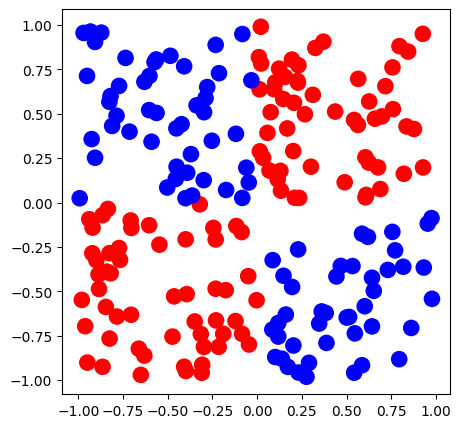

In [3]:
X = np.random.rand(200, 2) - 0.5
y = ((X[:, 0] < 0) ^ (X[:, 1] < 0))
X = X*2
show_data(X, y)

In [53]:

# <YOUR CODE STARTS HERE>
# 1. добавьте скрытые слои в модель (в первом из них не забудьте про input_shape)
#    ~3 скрытых слоев достаточно
# 2. добавьте выходной слой он должен быть без активации
# 3. определите оптимизатор
# 4. определите лосс (не забудьте указать from_logits=True!!)


#cоздаём модель
mode1 = tf.keras.Sequential(name='my_model')
#первый скрытый слой с input_shape
mode1.add(Dense(4, activation='relu', input_shape=(2,), name='hidden1'))
#ещё два скрытых слоя (всего 3)
mode1.add(Dense(8, activation='relu', name='hidden2'))
mode1.add(Dense(16, activation='relu', name='hidden3'))
#выходной слой БЕЗ АКТИВАЦИИ (важно для from_logits=True)
mode1.add(Dense(2, activation=None, name='output'))

mode1.summary()
tf.keras.utils.plot_model(mode1, show_shapes=True)

#определяем оптимизатор (например, Adam с learning_rate=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#определяем loss с from_logits=True (т.к. выходной слой без активации!)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)




# <YOUR CODE ENDS HERE>

mode1.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
history = mode1.fit(X, y, epochs=200, verbose=1, batch_size=64, shuffle=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230 (920.00 B)

 Trainable params: 230 (920.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5399 - loss: 0.8364
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5555 - loss: 0.8034
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5410 - loss: 0.7878
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5202 - loss: 0.7904
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5326 - loss: 0.7747
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5232 - loss: 0.7564
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5033 - loss: 0.7600
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5064 - loss: 0.7445
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4703 - loss: 0.7338
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4501 - loss: 0.7351
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4446 - loss: 0.7241
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4612 - lo

In [54]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss
0,0.545,0.824806
1,0.545,0.807160
2,0.540,0.792960
3,0.540,0.781466
4,0.545,0.770329


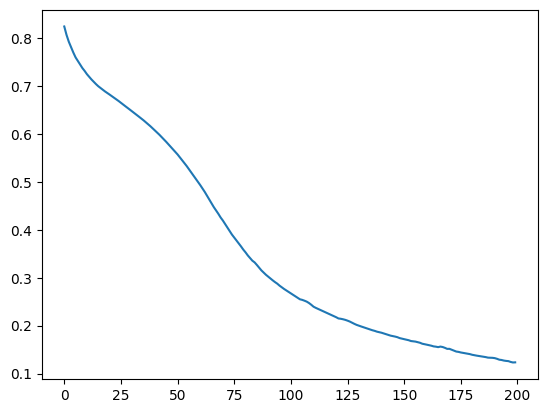

In [55]:
import matplotlib.pyplot as plt
plt.plot(history_df.loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9721 - loss: 0.1109  
Well done! Can you make 100%?


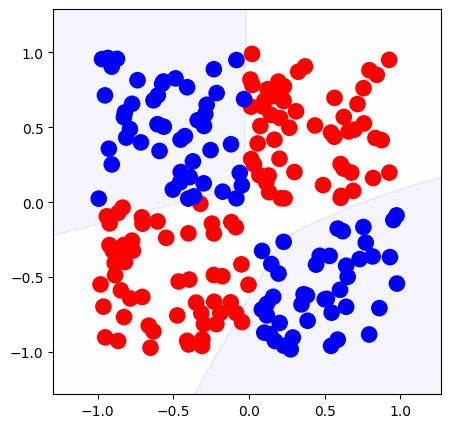

In [56]:
limits = [[-0.6, 0.6], [-0.6, 0.6]]
eval_model(mode1, X, y)
show_descision_boundary(limits=None, clf=mode1, binary=False,
                                X=X,
                                y=y,
                                n_lines=50,
                                show_lines=False)

In [16]:
inputlauer = tf.keras.layers.Input(shape = (2, ), name = "input")

l1 = Dense(32, name = "l1")
l1_output = l1(inputlauer)
l2_output = Dense(16, activation='relu', name = "l2")(l1_output)
l3_output = Dense(4, activation='relu', name = "l3")(l2_output)
#выходной слой БЕЗ активации
output = Dense(2, name = "output")(l3_output)
#собираем модель
model = tf.keras.Model(inputs=inputlauer, outputs=output, name="my_model")
#проверяем архитектуру
model.summary()

tf.keras.utils.plot_model(model, show_shapes=True)

#определяем оптимизатор (например, Adam с learning_rate=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#определяем loss с from_logits=True (т.к. выходной слой без активации!)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)




# <YOUR CODE ENDS HERE>

model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
history2 = model.fit(X, y, epochs=300, verbose=1, batch_size=64, shuffle=True)

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l1 (Dense)                      │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2 (Dense)                      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l3 (Dense)                      │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702 (2.74 KB)

 Trainable params: 702 (2.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4453 - loss: 0.7069
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4640 - loss: 0.6965
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4952 - loss: 0.6819
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4998 - loss: 0.6760
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6519 - loss: 0.6661
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7289 - loss: 0.6573
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8126 - loss: 0.6451
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8202 - loss: 0.6376
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8457 - loss: 0.6305
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8523 - loss: 0.6214
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8891 - loss: 0.6080
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8727 - lo

In [19]:
import pandas as pd
history2_df = pd.DataFrame(history2.history)
history2_df.head()

,accuracy,loss
0,0.440,0.706796
1,0.475,0.693686
2,0.475,0.683210
3,0.510,0.673716
4,0.665,0.664372


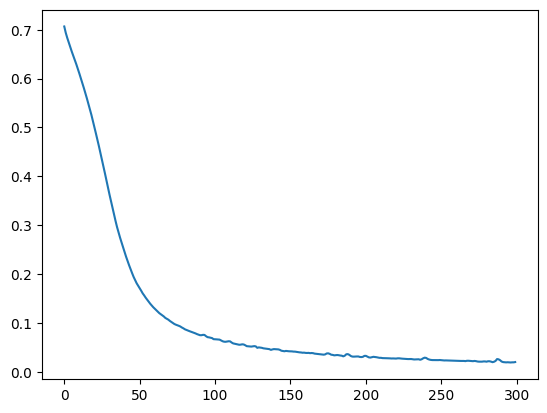

In [20]:
import matplotlib.pyplot as plt
plt.plot(history2_df.loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9931 - loss: 0.0215
Well done! Can you make 100%?


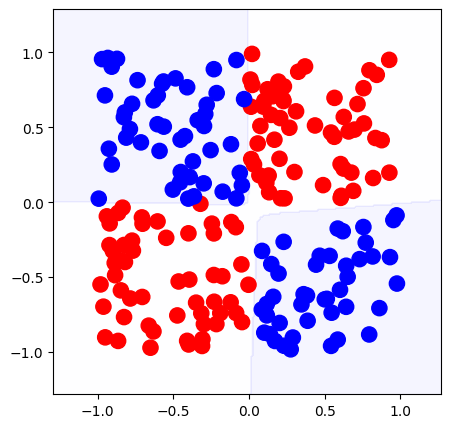

In [51]:

limits = [[-0.6, 0.6], [-0.6, 0.6]]
eval_model(model, X, y)
show_descision_boundary(limits=None, clf=model, binary=False,
                                X=X,
                                y=y,
                                n_lines=50,
                                show_lines=False)

**1b**

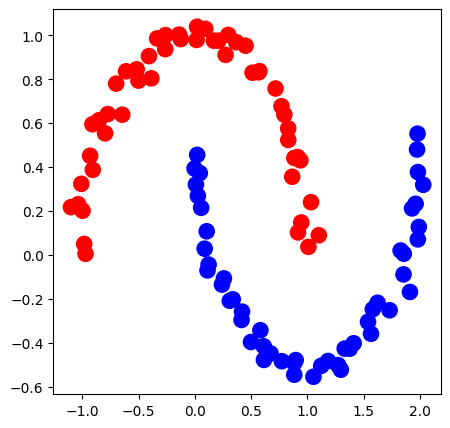

In [12]:
from sklearn.datasets import make_moons

X, y = make_moons(noise=0.04)
show_data(X, y)

In [24]:
model = tf.keras.Sequential()
# <YOUR CODE STARTS HERE>
# 1. добавьте скрытые слои в модель (в первом из них не забудьте про input_shape)
#    ~3 скрытых слоев достаточно
# 2. добавьте выходной слой он должен быть без активации
# 3. определите оптимизатор
# 4. определите лосс (не забудьте указать from_logits=True!!)
model.add(Dense(4, activation='relu', input_shape = (2, )))
model.add(Dense(8, activation='relu',))
model.add(Dense(16, activation='relu'))
model.add(Dense(16))
model.add(Dense(2, activation = None, name="output"))
model.summary()
tf.keras.utils.plot_model(model, show_shapes = False)


#определяем оптимизатор (например, Adam с learning_rate=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#определяем loss с from_logits=True (т.к. выходной слой без активации!)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)





# <YOUR CODE ENDS HERE>

model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
history = model.fit(X, y, epochs=300, verbose=1, batch_size=64, shuffle=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502 (1.96 KB)

 Trainable params: 502 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5052 - loss: 0.6868
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5067 - loss: 0.6733
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5029 - loss: 0.6672
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5000 - loss: 0.6525
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4896 - loss: 0.6411
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6631 - loss: 0.6304
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7952 - loss: 0.6204
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8160 - loss: 0.6071
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8160 - loss: 0.6008
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8160 - loss: 0.5895
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8056 - loss: 0.5795
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7900 - lo

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0065 
Perfect!


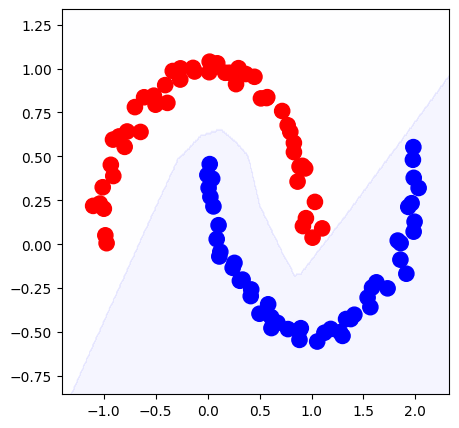

In [25]:
eval_model(model, X, y)
show_descision_boundary(limits=None, clf=model, binary=False,
                                X=X,
                                y=y,
                                n_lines=50,
                                show_lines=False)

In [26]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss
0,0.50,0.688123
1,0.51,0.675363
2,0.52,0.663064
3,0.50,0.650065
4,0.50,0.639214


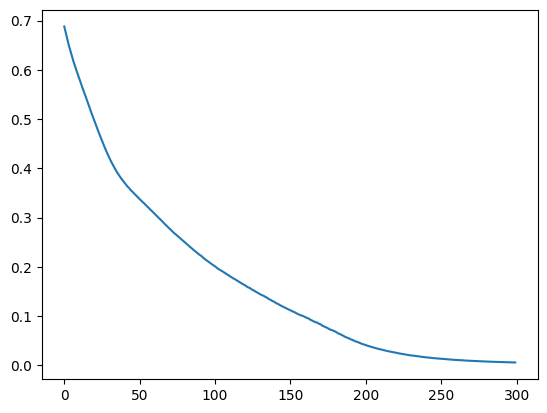

In [27]:
import matplotlib.pyplot as plt
plt.plot(history_df.loss)

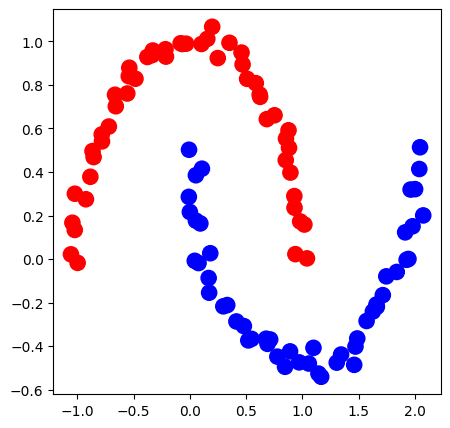

In [31]:
from sklearn.datasets import make_moons

X1, y1 = make_moons(noise=0.04)
show_data(X1, y1)

In [40]:
inputlauer = tf.keras.layers.Input(shape = (2, ), name = "input")

l1 = Dense(16, activation='relu', name = "l1")
l1_output = l1(inputlauer)
l2_output = Dense(8, activation='relu', name = "l2")(l1_output)
l3_output = Dense(4, activation='relu', name = "l3")(l2_output)
#выходной слой БЕЗ активации
output = Dense(2, name = "output")(l3_output)
#собираем модель
model3 = tf.keras.Model(inputs=inputlauer, outputs=output, name="my_model")
#проверяем архитектуру
model3.summary()

tf.keras.utils.plot_model(model3, show_shapes=True)

#определяем оптимизатор (например, Adam с learning_rate=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#определяем loss с from_logits=True (т.к. выходной слой без активации!)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)




# <YOUR CODE ENDS HERE>

model3.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
history3 = model3.fit(X1, y1, epochs=300, verbose=1, batch_size=64, shuffle=True)

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l1 (Dense)                      │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2 (Dense)                      │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l3 (Dense)                      │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230 (920.00 B)

 Trainable params: 230 (920.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7292 - loss: 0.6845
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7871 - loss: 0.6827
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7529 - loss: 0.6816
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7923 - loss: 0.6796
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8094 - loss: 0.6787
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8317 - loss: 0.6766
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8137 - loss: 0.6764
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8413 - loss: 0.6752
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8398 - loss: 0.6731
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8137 - loss: 0.6728
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8242 - loss: 0.6715
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8569 - lo

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9939 - loss: 0.0545 
Well done! Can you make 100%?


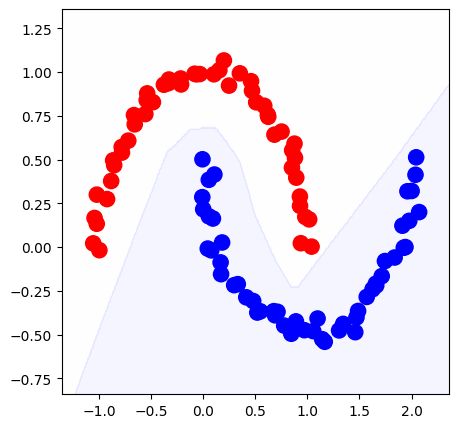

In [41]:
eval_model(model3, X1, y1)
show_descision_boundary(limits=None, clf=model, binary=False,
                                X=X1,
                                y=y1,
                                n_lines=50,
                                show_lines=False)

In [42]:
import pandas as pd
history_df = pd.DataFrame(history3.history)
history_df.head()

,accuracy,loss
0,0.75,0.684220
1,0.79,0.682543
2,0.77,0.681042
3,0.79,0.679652
4,0.80,0.678430


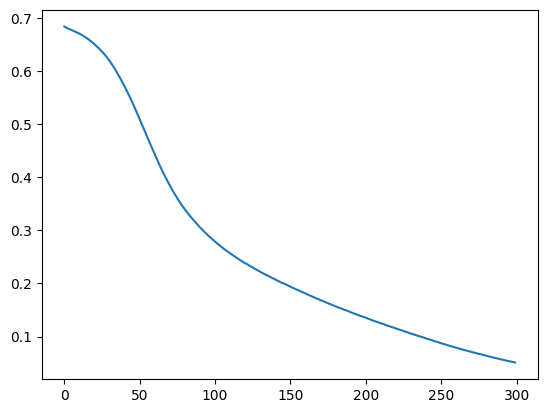

In [43]:
import matplotlib.pyplot as plt
plt.plot(history_df.loss)

**1c**

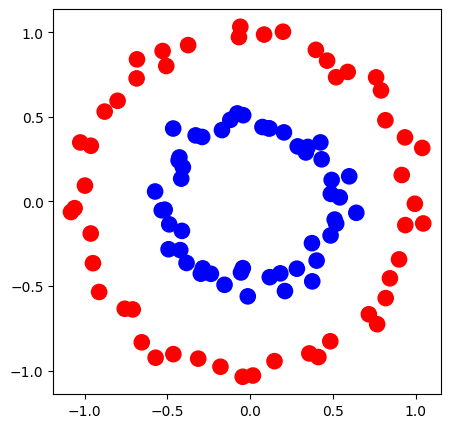

In [52]:
from sklearn.datasets import make_circles

X4, y4 = make_circles(factor=0.5, noise=0.05)
show_data(X4, y4)

In [53]:
model4 = tf.keras.Sequential()
# <YOUR CODE STARTS HERE>
# 1. добавьте скрытые слои в модель (в первом из них не забудьте про input_shape)
#    Постарайтесь сделать количество слоев и нейронов минимальным.
# 2. добавьте выходной слой он должен быть без активации
# 3. определите оптимизатор
# 4. определите лосс (не забудьте указать from_logits=True!!)
model4.add(Dense(8, activation='relu', input_shape = (2, )))
model4.add(Dense(16, activation='relu',))
model4.add(Dense(32, activation='relu'))
model4.add(Dense(16, activation='relu'))
model4.add(Dense(1, activation = None, name="output"))
model4.summary()
tf.keras.utils.plot_model(model4, show_shapes = False)


#определяем оптимизатор (например, Adam с learning_rate=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#определяем loss с from_logits=True (т.к. выходной слой без активации!)
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)





# <YOUR CODE ENDS HERE>

model4.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
history = model4.fit(X4, y4, epochs=80, verbose=1, batch_size=64, shuffle=True)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,257 (4.91 KB)

 Trainable params: 1,257 (4.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5000 - loss: 0.6931
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5156 - loss: 0.6923
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6906
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.6896
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5260 - loss: 0.6883
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4948 - loss: 0.6869
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4844 - loss: 0.6864
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6847
Epoch 9/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5208 - loss: 0.6826
Epoch 10/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4948 - loss: 0.6828
Epoch 11/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4740 - loss: 0.6825
Epoch 12/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5208 - loss: 0.6788
E

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0902
Perfect!
Model has 1257 parameters


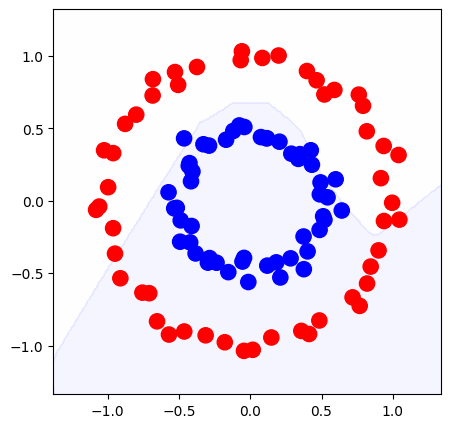

In [56]:
accuracy = eval_model(model4, X4, y4)
if model.count_params() < 18 and accuracy == 1.0:
    print("Bonus points!")
else:
    print(f"Model has {model4.count_params()} parameters")

show_descision_boundary(limits=None, clf=model, binary=False,
                                X=X4,
                                y=y4,
                                n_lines=50,
                                show_lines=False)

In [58]:
import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss
0,0.5,0.693433
1,0.5,0.692186
2,0.5,0.690689
3,0.5,0.689426
4,0.5,0.688434


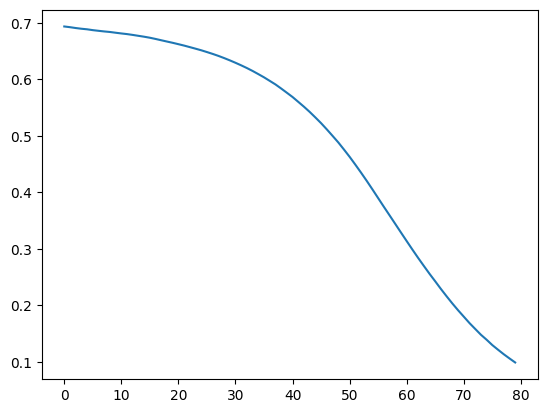

In [59]:
import matplotlib.pyplot as plt
plt.plot(history_df.loss)

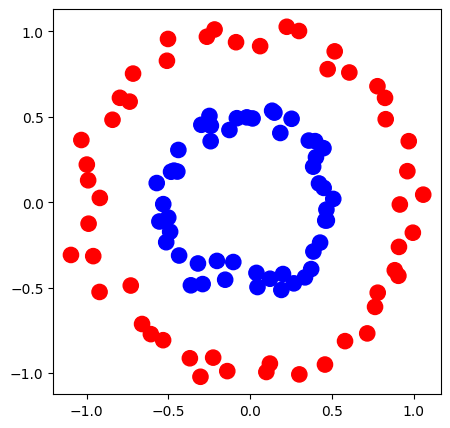

In [60]:
from sklearn.datasets import make_circles

X5, y5 = make_circles(factor=0.5, noise=0.05)
show_data(X5, y5)

In [61]:
model5 = tf.keras.Sequential([
    Dense(32, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model5.summary()
tf.keras.utils.plot_model(model5, show_shapes = False)


#определяем оптимизатор (например, Adam с learning_rate=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

#определяем loss с from_logits=True (т.к. выходной слой без активации!)
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)





# <YOUR CODE ENDS HERE>

model5.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
history5 = model5.fit(X5, y5, epochs=80, verbose=1, batch_size=64, shuffle=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_74 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5208 - loss: 0.7183
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4948 - loss: 0.7182
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4948 - loss: 0.7164
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.7155
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5104 - loss: 0.7113
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4948 - loss: 0.7096
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4710 - loss: 0.7092
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4710 - loss: 0.7071
Epoch 9/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4800 - loss: 0.7050
Epoch 10/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4762 - loss: 0.7036
Epoch 11/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4933 - loss: 0.7019
Epoch 12/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4985 - loss: 0.7003
Epoch 13/80


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.4608
Perfect!
Model has 769 parameters


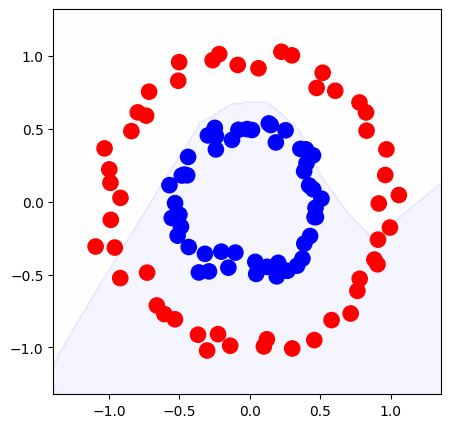

In [62]:
accuracy = eval_model(model5, X5, y5)
if model.count_params() < 18 and accuracy == 1.0:
    print("Bonus points!")
else:
    print(f"Model has {model5.count_params()} parameters")

show_descision_boundary(limits=None, clf=model, binary=False,
                                X=X5,
                                y=y5,
                                n_lines=50,
                                show_lines=False)

In [63]:
import pandas as pd
history_df = pd.DataFrame(history5.history)
history_df.head()

,accuracy,loss
0,0.5,0.720574
1,0.5,0.718228
2,0.5,0.716155
3,0.5,0.714178
4,0.5,0.712025


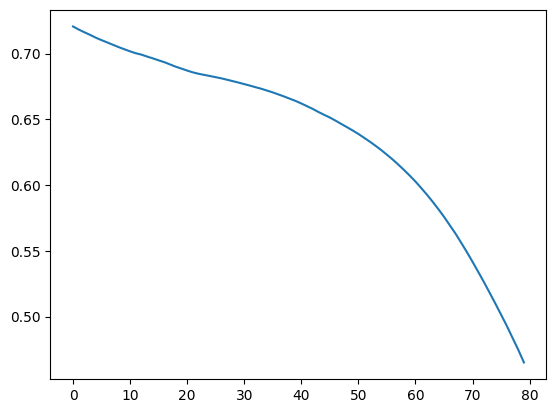

In [64]:
import matplotlib.pyplot as plt
plt.plot(history_df.loss)